In [3]:
import os

import torch
from diffusers import DDIMScheduler, AutoencoderKL
from PIL import Image
from safetensors.torch import load_model

from powerpaint.pipelines import StableDiffusionInpaintIndomainPipeline
from powerpaint.utils.utils import TokenizerWrapper, add_tokens
from ip_adapter import IPAdapter

In [4]:
base_model_path = '/mnt/disk2/hachi/checkpoints/stable-diffusion-inpainting'
ppt1_checkpoint = '/mnt/disk2/hachi/checkpoints/ppt-v1'
image_encoder_path = "models/image_encoder/"
ip_ckpt = "models/ip-adapter_sd15.bin"
device = "cuda:1"

In [ ]:
### Load base model
pipe = StableDiffusionInpaintIndomainPipeline.from_pretrained(
        base_model_path,
        torch_dtype=torch.float16,
        local_files_only=True
)
pipe.tokenizer = TokenizerWrapper(
        from_pretrained=base_model_path,
        subfolder='tokenizer',
        torch_dtype=torch.float16,
        local_files_only=True
)

# add pretrained learned task tokens into the tokenizer
add_tokens(
    tokenizer=pipe.tokenizer,
    text_encoder=pipe.text_encoder,
    placeholder_tokens=["P_ctxt", "P_shape", "P_obj"],
    initialize_tokens=["a", "a", "a"],
    num_vectors_per_token=10,
)
# load ppt1 checkpoint
load_model(pipe.unet, os.path.join(ppt1_checkpoint, "unet/unet.safetensors"), strict=False)
load_model(pipe.text_encoder, os.path.join(ppt1_checkpoint, "text_encoder/text_encoder.safetensors"),strict=False )


In [5]:
def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols

    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    grid_w, grid_h = grid.size
    
    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid

def expand_bbox(bbox, image_size, scale=1.3):
    """
    bbox: [x_min, y_min, x_max, y_max]
    image_size: (width, height)
    scale: hệ số mở rộng bbox
    """
    x_min, y_min, x_max, y_max = bbox
    img_w, img_h = image_size

    # Kích thước bbox gốc
    w = x_max - x_min
    h = y_max - y_min

    # Tâm bbox
    cx = (x_min + x_max) / 2
    cy = (y_min + y_max) / 2

    # Kích thước mới
    new_w = w * scale
    new_h = h * scale

    # Tính bbox mới
    new_x_min = int(cx - new_w / 2)
    new_y_min = int(cy - new_h / 2)
    new_x_max = int(cx + new_w / 2)
    new_y_max = int(cy + new_h / 2)

    # Clamp vào biên ảnh
    new_x_min = max(0, new_x_min)
    new_y_min = max(0, new_y_min)
    new_x_max = min(img_w, new_x_max)
    new_y_max = min(img_h, new_y_max)

    return [new_x_min, new_y_min, new_x_max, new_y_max]


In [6]:
# read image prompt
bbox = [494, 227, 580, 313]
image = Image.open("/mnt/disk1/aiotlab/hachi/PowerPaint/validation/test/2_b1/ground_truth.png")
expanded_bbox = expand_bbox(
    bbox=bbox,
    image_size=image.size,
    scale=1.5   # bạn có thể thử 1.2 – 1.5
)

cropped_image = image.crop(expanded_bbox)

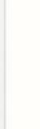

In [7]:
cropped_image

In [ ]:
masked_image = Image.open("/mnt/disk1/aiotlab/hachi/PowerPaint/validation/test/2_b1/ground_truth.png").resize((512, 768))
mask = Image.open("/mnt/disk1/aiotlab/hachi/PowerPaint/validation/test/2_b1/mask.png").resize((512, 768))
image_grid([masked_image.resize((256, 384)), mask.resize((256, 384))], 1, 2)

In [ ]:
# load ip-adapter
ip_model = IPAdapter(pipe, image_encoder_path, ip_ckpt, device)

In [ ]:
# generate
images = ip_model.generate(pil_image=image, num_samples=4, num_inference_steps=50,
                           seed=42, image=masked_image, mask_image=mask, strength=0.7, )
grid = image_grid(images, 1, 4)
grid